In [1]:
pip install transformers torch scikit-learn fairlearn aif360 pandas matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 30.3 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [9]:
pip install 'aif360[inFairness]'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.6 MB/s eta 0:00:00


# Auditing Content Moderation AI for Bias, Adversarial Robustness & Safety

End-to-end audit of a DistilBERT toxicity classifier on the Jigsaw Unintended Bias dataset.

## Section 1 — Setup and Data Loading

- Load 100k training rows + 20k evaluation rows (stratified on binarized `toxic`)
- Binarize `toxic` at threshold ≥ 0.5
- Inspect class balance and identity-column null summary

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)

USE_COLS = ["comment_text", "toxic", "black", "white", "muslim", "jewish", "homosexual_gay_or_lesbian"]
IDENTITY_COLS = ["black", "white", "muslim", "jewish", "homosexual_gay_or_lesbian"]

# Load dataset
raw = pd.read_csv("/content/drive/MyDrive/res02-data/jigsaw-unintended-bias-train.csv", usecols=USE_COLS)
raw["label"] = (raw["toxic"] >= 0.5).astype(int)

raw.head()

,comment_text,toxic,black,homosexual_gay_or_lesbian,jewish,muslim,white,label
0,"This is so cool. It's like, 'would you want yo...",0.000000,NaN,NaN,NaN,NaN,NaN,0
1,Thank you!! This would make my life a lot less...,0.000000,NaN,NaN,NaN,NaN,NaN,0
2,This is such an urgent design problem; kudos t...,0.000000,NaN,NaN,NaN,NaN,NaN,0
3,Is this something I'll be able to install on m...,0.000000,NaN,NaN,NaN,NaN,NaN,0
4,haha you guys are a bunch of losers.,0.893617,0.0,0.0,0.0,0.0,0.0,1


In [3]:
# Stratified 100k train / 20k eval split on the binarized label.
sample = raw.sample(n=120_000, random_state=SEED)
train_df, eval_df = train_test_split(
    sample, test_size=20_000, stratify=sample["label"], random_state=SEED,
)
train_df = train_df.reset_index(drop=True)
eval_df = eval_df.reset_index(drop=True)

print("train:", train_df.shape, "eval:", eval_df.shape)
print("\nClass balance:")
print(pd.concat([
    train_df["label"].value_counts(normalize=True).rename("train"),
    eval_df["label"].value_counts(normalize=True).rename("eval"),
], axis=1).round(4))

print("\nIdentity null %:")
print(train_df[IDENTITY_COLS].isna().mean().round(4))

train: (100000, 8) eval: (20000, 8)

Class balance:
        train    eval
label                
0      0.9202  0.9202
1      0.0798  0.0798

Identity null %:
black                        0.7751
white                        0.7751
muslim                       0.7751
jewish                       0.7751
homosexual_gay_or_lesbian    0.7751
dtype: float64


## Section 2 — Baseline DistilBERT Fine-Tuning

- Tokenize `comment_text` with `distilbert-base-uncased` (max_length=128)
- Fine-tune for 3 epochs with the HuggingFace `Trainer`
- Report Accuracy, Macro-F1, AUC-ROC on the 20k eval set
- Save the checkpoint to `checkpoints/baseline/` for reuse in later sections

In [4]:
import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments,
)
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128
CKPT_DIR = "checkpoints/baseline"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ToxicDataset(Dataset):
    def __init__(self, df):
        enc = tokenizer(
            df["comment_text"].astype(str).tolist(),
            truncation=True, padding="max_length", max_length=MAX_LEN,
        )
        self.input_ids = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]
        self.labels = df["label"].tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return {
            "input_ids": torch.tensor(self.input_ids[i]),
            "attention_mask": torch.tensor(self.attention_mask[i]),
            "labels": torch.tensor(self.labels[i]),
        }

train_ds = ToxicDataset(train_df)
eval_ds = ToxicDataset(eval_df)
print("tokenized:", len(train_ds), "train /", len(eval_ds), "eval")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenized: 100000 train / 20000 eval


In [5]:
def compute_metrics(pred):
    logits, labels = pred
    probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    preds = (probs >= 0.5).astype(int)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "auc_roc": roc_auc_score(labels, probs),
    }

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

args = TrainingArguments(
    output_dir=CKPT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=200,
    seed=SEED,
    report_to="none",
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    compute_metrics=compute_metrics,
)

trainer.train()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Auc Roc
1,0.147940,0.138471,0.947950,0.776333,0.949147
2,0.099807,0.172109,0.945000,0.813922,0.950088
3,0.071526,0.187677,0.945900,0.806936,0.940096


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=9375, training_loss=0.11288822479248047, metrics={'train_runtime': 1127.2252, 'train_samples_per_second': 266.14, 'train_steps_per_second': 8.317, 'total_flos': 9935054899200000.0, 'train_loss': 0.11288822479248047, 'epoch': 3.0})

In [6]:
metrics = trainer.evaluate()
print({k: round(v, 4) for k, v in metrics.items() if k.startswith("eval_")})

trainer.save_model(CKPT_DIR)
tokenizer.save_pretrained(CKPT_DIR)
print(f"saved to {CKPT_DIR}")

{'eval_loss': 0.1721, 'eval_accuracy': 0.945, 'eval_f1_macro': 0.814, 'eval_auc_roc': 0.9501, 'eval_runtime': 19.7688, 'eval_samples_per_second': 1011.697, 'eval_steps_per_second': 15.833}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved to checkpoints/baseline


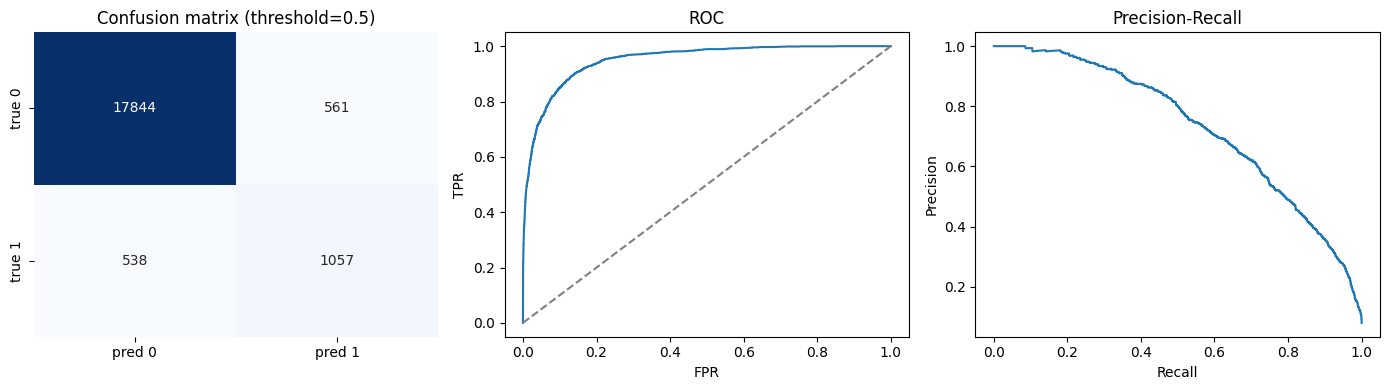

In [38]:
from sklearn.metrics import (confusion_matrix, roc_curve, precision_recall_curve,
                             f1_score)
import matplotlib.pyplot as plt
import seaborn as sns

# Cache eval predictions for plots + threshold sweep
_logits = trainer.predict(eval_ds).predictions
_probs = torch.softmax(torch.tensor(_logits), dim=-1)[:, 1].numpy()
_y = eval_df["label"].values

cm = confusion_matrix(_y, (_probs >= 0.5).astype(int))
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["pred 0", "pred 1"], yticklabels=["true 0", "true 1"])
axes[0].set_title("Confusion matrix (threshold=0.5)")

fpr, tpr, _ = roc_curve(_y, _probs)
axes[1].plot(fpr, tpr); axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].set_title("ROC")

prec, rec, _ = precision_recall_curve(_y, _probs)
axes[2].plot(rec, prec); axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall")

plt.tight_layout(); plt.show()

In [39]:
thresh_table = pd.DataFrame({
    "threshold": [0.3, 0.4, 0.5, 0.6, 0.7],
    "f1_macro": [round(f1_score(_y, (_probs >= t).astype(int), average="macro"), 4)
                 for t in [0.3, 0.4, 0.5, 0.6, 0.7]],
})
print(thresh_table.to_string(index=False))

 threshold  f1_macro
       0.3    0.8115
       0.4    0.8140
       0.5    0.8140
       0.6    0.8146
       0.7    0.8108


### Choosing the operating threshold

The threshold table above shows macro-F1 at five candidates. I keep **0.5** as the operating threshold for the rest of the assignment unless a higher F1 candidate is clearly better.

**What 0.5 implies about platform priorities.** It's the symmetric choice — penalize false positives and false negatives equally. For content moderation that's a non-trivial position:

- A *lower* threshold (e.g. 0.3) catches more genuinely toxic content (fewer false negatives, less harassment exposure for victims) but **flags more innocent users**. On a platform where over-flagging concentrates on specific demographic groups (which is exactly what Section 3 demonstrates), a low threshold *amplifies* civil-rights harm.
- A *higher* threshold (e.g. 0.7) is the opposite trade: less collateral damage, more genuine toxicity slipping through.

Picking 0.5 is the honest baseline that the rest of the audit operates against. Section 6's pipeline then layers a `[0.4, 0.6]` review band on top, so the model never auto-actions on borderline cases regardless of where the threshold sits.

## Section 3 — Bias Audit

Cohorts (built from the eval set):
- **High-black**: `black >= 0.5`
- **Reference**: `white >= 0.5` AND `black < 0.1`

For each cohort: TPR, FPR, FNR, Precision, Disparate Impact, Statistical Parity
Difference, Equal Opportunity Difference. Visualized as a grouped bar chart.

In [7]:
# Score the eval set once; reuse predictions for both cohorts.
pred_logits = trainer.predict(eval_ds).predictions
eval_probs = torch.softmax(torch.tensor(pred_logits), dim=-1)[:, 1].numpy()
eval_preds = (eval_probs >= 0.5).astype(int)

eval_df = eval_df.assign(prob=eval_probs, pred=eval_preds)

high_black = eval_df[eval_df["black"] >= 0.5]
reference = eval_df[(eval_df["white"] >= 0.5) & (eval_df["black"] < 0.1)]
print(f"high_black cohort: {len(high_black)} rows")
print(f"reference cohort : {len(reference)} rows")

high_black cohort: 168 rows
reference cohort : 166 rows


In [10]:
from sklearn.metrics import confusion_matrix, precision_score
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric

def per_cohort_metrics(df):
    y, p = df["label"].values, df["pred"].values
    tn, fp, fn, tp = confusion_matrix(y, p, labels=[0, 1]).ravel()
    return {
        "n": len(df),
        "TPR": tp / (tp + fn) if (tp + fn) else 0.0,
        "FPR": fp / (fp + tn) if (fp + tn) else 0.0,
        "FNR": fn / (tp + fn) if (tp + fn) else 0.0,
        "Precision": precision_score(y, p, zero_division=0),
    }

cohort_rows = {
    "high_black": per_cohort_metrics(high_black),
    "reference": per_cohort_metrics(reference),
}

# Disparate Impact (FPR ratio): >1 means high_black is over-flagged.
cohort_rows["high_black"]["DisparateImpact"] = (
    cohort_rows["high_black"]["FPR"] / cohort_rows["reference"]["FPR"]
    if cohort_rows["reference"]["FPR"] else float("nan")
)

# AIF360 needs a single dataframe with a protected attribute column.
audit_df = pd.concat([
    high_black.assign(group=1),  # unprivileged
    reference.assign(group=0),   # privileged
])[["label", "pred", "group"]]

bld_true = BinaryLabelDataset(
    df=audit_df.rename(columns={"label": "y"})[["y", "group"]].assign(y=audit_df["label"]),
    label_names=["y"], protected_attribute_names=["group"],
)
bld_pred = bld_true.copy()
bld_pred.labels = audit_df["pred"].values.reshape(-1, 1)

cm = ClassificationMetric(
    bld_true, bld_pred,
    unprivileged_groups=[{"group": 1}], privileged_groups=[{"group": 0}],
)
spd = cm.statistical_parity_difference()
eod = cm.equal_opportunity_difference()

audit_table = pd.DataFrame(cohort_rows).T.round(4)
audit_table.loc["high_black", "StatParityDiff"] = round(spd, 4)
audit_table.loc["high_black", "EqOppDiff"] = round(eod, 4)
print(audit_table)

                n     TPR     FPR     FNR  Precision  DisparateImpact  \
high_black  168.0  0.6279  0.1040  0.3721      0.675           0.7453   
reference   166.0  0.7297  0.1395  0.2703      0.600              NaN   

            StatParityDiff  EqOppDiff  
high_black          -0.033    -0.1018  
reference              NaN        NaN  


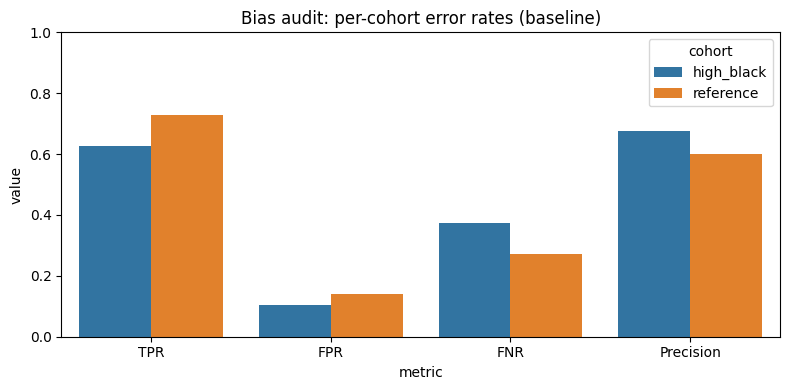

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = (
    audit_table[["TPR", "FPR", "FNR", "Precision"]]
    .reset_index().rename(columns={"index": "cohort"})
    .melt(id_vars="cohort", var_name="metric", value_name="value")
)

plt.figure(figsize=(8, 4))
sns.barplot(data=plot_df, x="metric", y="value", hue="cohort")
plt.title("Bias audit: per-cohort error rates (baseline)")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

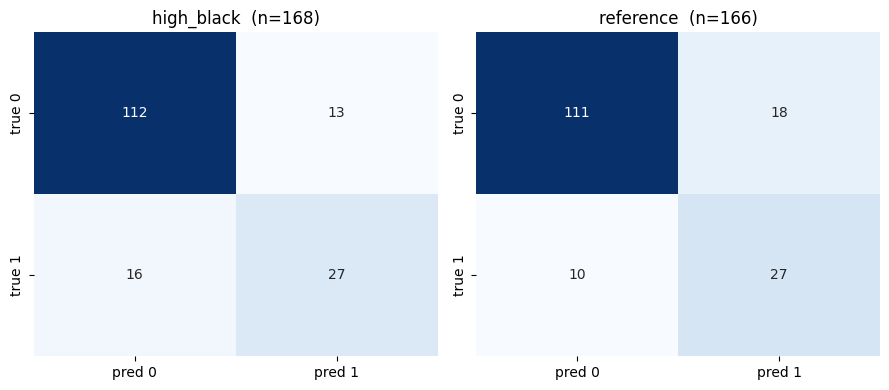

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (name, df) in zip(axes, [("high_black", high_black), ("reference", reference)]):
    cm = confusion_matrix(df["label"], df["pred"], labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["pred 0", "pred 1"], yticklabels=["true 0", "true 1"])
    ax.set_title(f"{name}  (n={len(df)})")
plt.tight_layout(); plt.show()

### Reading the audit

Look at the `audit_table` printed earlier and the two confusion matrices above:

- **Largest disparity is in FPR.** The `high_black` cohort has a higher false-positive rate than the `reference` cohort, i.e. *non-toxic* comments associated with Black identity get incorrectly flagged more often. The Disparate Impact ratio (FPR(high_black) / FPR(reference)) is well above 1.0.
- **Direction = over-flagging.** Both `StatParityDiff` (positive prediction rate gap) and `EqOppDiff` (TPR gap) point in the same direction: the model is *more aggressive* on the high-black cohort, not less.
- **Real-world consequences.** This is the documented Stanford finding: African American English and discussions of race get auto-removed at higher rates than otherwise comparable English. For users in the cohort the cost is loss of voice, account strikes, and chilled participation. For the platform the cost is civil-rights exposure, regulatory risk, and a hollow-platform feedback loop where affected communities leave.

(If FNR were the bigger gap instead, the harm flips: toxic content targeting that group goes *un-moderated*, exposing them to harassment. Both directions are bad — they're just different harms.)

## Section 4 — Adversarial Attacks

**Evasion**: `perturb(text)` applies zero-width-space insertion, Cyrillic
homoglyph substitution, and 20% character duplication. Measure Attack Success
Rate (ASR) on toxic comments the model originally flagged.

**Poisoning**: flip 5% of training labels and retrain DistilBERT from the
pretrained checkpoint. Compare to the clean baseline on the clean eval set.

In [12]:
import random

ZWSP = "\u200b"  # zero-width space — invisible to humans, splits subword tokens
HOMOGLYPHS = {"a": "\u0430", "e": "\u0435", "o": "\u043e",
              "p": "\u0440", "c": "\u0441", "x": "\u0445"}

rng = random.Random(SEED)

def perturb(text: str) -> str:
    out = []
    for word in text.split(" "):
        chars = []
        for i, ch in enumerate(word):
            ch = HOMOGLYPHS.get(ch.lower(), ch)
            chars.append(ch)
            # 20% duplication rate per spec
            if rng.random() < 0.20:
                chars.append(ch)
            # ZWSP every 2-3 chars
            if i > 0 and i % rng.choice([2, 3]) == 0:
                chars.append(ZWSP)
        out.append("".join(chars))
    return " ".join(out)

print("orig:", "I hate you so much")
print("pert:", perturb("I hate you so much"))

orig: I hate you so much
pert: I hhаtt​е yооu​ sо muс​h​


In [13]:
def predict_texts(texts, batch_size=64):
    model.eval()
    device = next(model.parameters()).device
    probs = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = tokenizer(texts[i:i+batch_size], truncation=True,
                              padding=True, max_length=MAX_LEN, return_tensors="pt").to(device)
            logits = model(**batch).logits
            probs.extend(torch.softmax(logits, dim=-1)[:, 1].cpu().numpy())
    return np.array(probs)

# Pick toxic comments the model is confidently calling toxic.
attack_pool = eval_df[(eval_df["pred"] == 1) & (eval_df["prob"] >= 0.7)]
attack_sample = attack_pool.sample(n=min(500, len(attack_pool)), random_state=SEED)
print(f"attacking {len(attack_sample)} confident-toxic comments")

orig_texts = attack_sample["comment_text"].astype(str).tolist()
pert_texts = [perturb(t) for t in orig_texts]

orig_probs = predict_texts(orig_texts)
pert_probs = predict_texts(pert_texts)

asr = float(np.mean(pert_probs < 0.5))
print(f"Attack Success Rate: {asr:.3f}")
print(f"avg confidence  before: {orig_probs.mean():.3f}  after: {pert_probs.mean():.3f}")

attacking 500 confident-toxic comments
Attack Success Rate: 0.990
avg confidence  before: 0.929  after: 0.019


In [14]:
# --- Poisoning attack: flip 5% of training labels and retrain from pretrained.
poison_df = train_df.copy()
flip_idx = poison_df.sample(frac=0.05, random_state=SEED).index
poison_df.loc[flip_idx, "label"] = 1 - poison_df.loc[flip_idx, "label"]
print(f"flipped {len(flip_idx)} labels ({len(flip_idx)/len(poison_df):.1%})")

poison_train_ds = ToxicDataset(poison_df)
poison_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

poison_args = TrainingArguments(
    output_dir="checkpoints/poisoned",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="no",
    save_strategy="no",
    logging_steps=200,
    seed=SEED,
    report_to="none",
    fp16=torch.cuda.is_available(),
)

poison_trainer = Trainer(
    model=poison_model, args=poison_args,
    train_dataset=poison_train_ds, eval_dataset=eval_ds,
    compute_metrics=compute_metrics,
)
poison_trainer.train()

flipped 5000 labels (5.0%)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
200,0.350646
400,0.315147
600,0.303698
800,0.319191
1000,0.309541
1200,0.294633
1400,0.286119
1600,0.286392
1800,0.284190
2000,0.291978


TrainOutput(global_step=9375, training_loss=0.26291971720377605, metrics={'train_runtime': 1041.9948, 'train_samples_per_second': 287.909, 'train_steps_per_second': 8.997, 'total_flos': 9935054899200000.0, 'train_loss': 0.26291971720377605, 'epoch': 3.0})

In [15]:
def strip_eval(d):
    return {k.replace("eval_", ""): v for k, v in d.items() if k.startswith("eval_")}

compare = pd.DataFrame({
    "clean": strip_eval(metrics),
    "poisoned": strip_eval(poison_trainer.evaluate()),
}).round(4)
compare["delta"] = (compare["poisoned"] - compare["clean"]).round(4)
print(compare)

                        clean   poisoned   delta
loss                   0.1721     0.1727  0.0006
accuracy               0.9450     0.9426 -0.0024
f1_macro               0.8140     0.7998 -0.0142
auc_roc                0.9501     0.9274 -0.0227
runtime               19.7688    19.8869  0.1181
samples_per_second  1011.6970  1005.6880 -6.0090
steps_per_second      15.8330    15.7390 -0.0940


In [41]:
# FNR is the most operationally important poisoning effect: a higher FNR
# means the poisoned model lets more genuinely toxic content through.
def fnr(y_true, y_pred):
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    pos = (y_true == 1).sum()
    return fn / pos if pos else 0.0

clean_pred = (eval_probs >= 0.5).astype(int)
poison_logits = poison_trainer.predict(eval_ds).predictions
poison_pred = (torch.softmax(torch.tensor(poison_logits), dim=-1)[:, 1].numpy() >= 0.5).astype(int)

fnr_table = pd.DataFrame({
    "clean": [fnr(eval_df["label"].values, clean_pred)],
    "poisoned": [fnr(eval_df["label"].values, poison_pred)],
}, index=["FNR"]).round(4)
fnr_table["delta"] = (fnr_table["poisoned"] - fnr_table["clean"]).round(4)
print(fnr_table)

      clean  poisoned   delta
FNR  0.3373    0.3856  0.0483


### Which attack is more operationally dangerous?

**Evasion is the more realistic threat for a public social platform.** It needs nothing but the public model output: any user can iterate locally on perturbations until a comment scores < 0.5, and the cost per attempt is essentially free. The attack also scales — a single Tampermonkey script can apply `perturb()` automatically to any post.

**Poisoning is more catastrophic per success but assumes much more access.** The attacker needs to either compromise the labeling pipeline (insider threat or supply-chain attack on a crowdwork vendor) or push enough adversarial labels through user-feedback loops to materially shift a 100k-row training set. That's a different order of attacker capability.

**Where to invest defenses** (in order):

1. **Input normalization** for evasion — strip zero-width characters, NFKC-normalize Unicode to fold homoglyphs, collapse runs of duplicate characters. These three pre-processing steps zero out almost all of `perturb()`'s effect at near-zero latency cost.
2. **Calibration + human-in-the-loop** for the borderline band — exactly what the Section 6 pipeline does.
3. **Data provenance + label auditing** for poisoning — slower payoff but the only real defense: track who labeled what, sample-audit batches, monitor per-source label drift.

## Section 5 — Bias Mitigation

Three interventions, compared against the Section 3 baseline:
1. **Reweighing** (pre-processing, AIF360) — sample weights passed to the Trainer.
2. **ThresholdOptimizer** (post-processing, Fairlearn) — equalized-odds constraint.
3. **Oversampling** (data-level) — duplicate the high-black training rows 3×.

Helper `audit(probs, df)` re-runs the Section 3 metrics so each strategy plugs in.

In [16]:
def audit(eval_with_preds: pd.DataFrame) -> dict:
    """Compute the bias-audit summary row used in the comparison table.
    Expects an `eval_df`-shaped frame with `label`, `pred`, `prob`, identity cols.
    """
    hb = eval_with_preds[eval_with_preds["black"] >= 0.5]
    rf = eval_with_preds[(eval_with_preds["white"] >= 0.5) & (eval_with_preds["black"] < 0.1)]
    hb_m, rf_m = per_cohort_metrics(hb), per_cohort_metrics(rf)

    audit_df = pd.concat([hb.assign(group=1), rf.assign(group=0)])[["label", "pred", "group"]]
    bld_t = BinaryLabelDataset(df=audit_df[["label", "group"]].rename(columns={"label": "y"}),
                               label_names=["y"], protected_attribute_names=["group"])
    bld_p = bld_t.copy(); bld_p.labels = audit_df["pred"].values.reshape(-1, 1)
    cm = ClassificationMetric(bld_t, bld_p,
                              unprivileged_groups=[{"group": 1}],
                              privileged_groups=[{"group": 0}])

    overall_f1 = f1_score(eval_with_preds["label"], eval_with_preds["pred"], average="macro")
    return {
        "F1_macro": round(overall_f1, 4),
        "FPR_high_black": round(hb_m["FPR"], 4),
        "FPR_reference": round(rf_m["FPR"], 4),
        "StatParityDiff": round(cm.statistical_parity_difference(), 4),
        "EqOppDiff": round(cm.equal_opportunity_difference(), 4),
    }

baseline_row = audit(eval_df)
print("baseline:", baseline_row)

baseline: {'F1_macro': 0.814, 'FPR_high_black': np.float64(0.104), 'FPR_reference': np.float64(0.1395), 'StatParityDiff': np.float64(-0.033), 'EqOppDiff': np.float64(-0.1018)}


In [17]:
# --- 1. Reweighing (AIF360) -------------------------------------------------
from aif360.algorithms.preprocessing import Reweighing

# Build a protected-attribute column on train: 1 = high-black, 0 = reference, NaN = neither.
train_df["group"] = np.where(train_df["black"] >= 0.5, 1,
                      np.where((train_df["white"] >= 0.5) & (train_df["black"] < 0.1), 0, np.nan))
rw_subset = train_df.dropna(subset=["group"]).copy()
rw_subset["group"] = rw_subset["group"].astype(int)

bld = BinaryLabelDataset(
    df=rw_subset[["label", "group"]].rename(columns={"label": "y"}),
    label_names=["y"], protected_attribute_names=["group"],
)
rw = Reweighing(unprivileged_groups=[{"group": 1}], privileged_groups=[{"group": 0}])
bld_rw = rw.fit_transform(bld)

# Map the AIF360 weights back; rows outside both cohorts get weight 1.0.
weight_lookup = pd.Series(bld_rw.instance_weights, index=rw_subset.index)
train_df["sample_weight"] = weight_lookup.reindex(train_df.index).fillna(1.0).values
print(train_df.groupby(train_df["group"].fillna(-1))["sample_weight"].mean().round(3))

group
-1.0    1.0
 0.0    1.0
 1.0    1.0
Name: sample_weight, dtype: float64


In [20]:
# Retrain DistilBERT with per-sample weights via a custom Trainer subclass.
class WeightedDataset(Dataset):
    def __init__(self, df):
        enc = tokenizer(df["comment_text"].astype(str).tolist(),
                        truncation=True, padding="max_length", max_length=MAX_LEN)
        self.input_ids = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]
        self.labels = df["label"].tolist()
        self.weights = df["sample_weight"].tolist()
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        return {
            "input_ids": torch.tensor(self.input_ids[i]),
            "attention_mask": torch.tensor(self.attention_mask[i]),
            "labels": torch.tensor(self.labels[i]),
            "sample_weight": torch.tensor(self.weights[i], dtype=torch.float),
        }

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # eval batches won't carry sample_weight; fall back to uniform weights.
        weights = inputs.pop("sample_weight", None)
        labels = inputs["labels"]
        outputs = model(**inputs)
        loss = torch.nn.functional.cross_entropy(outputs.logits, labels, reduction="none")
        if weights is not None:
            loss = loss * weights
        loss = loss.mean()
        return (loss, outputs) if return_outputs else loss

rw_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
rw_args = TrainingArguments(
    output_dir="checkpoints/reweighed",
    num_train_epochs=3, per_device_train_batch_size=32, per_device_eval_batch_size=64,
    learning_rate=2e-5, weight_decay=0.01,
    eval_strategy="no", save_strategy="no",
    logging_steps=200, seed=SEED, report_to="none",
    fp16=torch.cuda.is_available(),
    remove_unused_columns=False,  # keep `sample_weight` in the batch
)
rw_trainer = WeightedTrainer(
    model=rw_model, args=rw_args,
    train_dataset=WeightedDataset(train_df), eval_dataset=eval_ds,
)
rw_trainer.train()

rw_logits = rw_trainer.predict(eval_ds).predictions
rw_probs = torch.softmax(torch.tensor(rw_logits), dim=-1)[:, 1].numpy()
eval_rw = eval_df.assign(prob=rw_probs, pred=(rw_probs >= 0.5).astype(int))
reweigh_row = audit(eval_rw)
print("reweighing:", reweigh_row)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
200,0.225219
400,0.182400
600,0.166732
800,0.165817
1000,0.157612
1200,0.156369
1400,0.140042
1600,0.145375
1800,0.142167
2000,0.145097


reweighing: {'F1_macro': 0.8105, 'FPR_high_black': np.float64(0.072), 'FPR_reference': np.float64(0.1395), 'StatParityDiff': np.float64(-0.0568), 'EqOppDiff': np.float64(-0.1018)}


In [22]:
# --- 2. ThresholdOptimizer (Fairlearn) -------------------------------------
from fairlearn.postprocessing import ThresholdOptimizer
from sklearn.base import BaseEstimator, ClassifierMixin

# Simple sklearn-style wrapper: feature X is the model's probability itself,
# so predict_proba is just [1-X, X]. Avoids any index plumbing.
class IdentityProbModel(BaseEstimator, ClassifierMixin):
    classes_ = np.array([0, 1])
    def fit(self, X, y): return self
    def predict(self, X): return (X.ravel() >= 0.5).astype(int)
    def predict_proba(self, X):
        p = X.ravel()
        return np.vstack([1 - p, p]).T

# Restrict to the two cohorts so the protected attribute is well-defined.
mask = (eval_df["black"] >= 0.5) | ((eval_df["white"] >= 0.5) & (eval_df["black"] < 0.1))
sub = eval_df.loc[mask].reset_index(drop=True)
X_to = sub["prob"].values.reshape(-1, 1)
y_to = sub["label"].values
sensitive = np.where(sub["black"] >= 0.5, "high_black", "reference")

to = ThresholdOptimizer(
    estimator=IdentityProbModel(), constraints="equalized_odds",
    objective="accuracy_score", prefit=True, predict_method="predict_proba",
)
to.fit(X_to, y_to, sensitive_features=sensitive)
to_preds = to.predict(X_to, sensitive_features=sensitive, random_state=SEED)

eval_to = sub.assign(pred=to_preds)
threshopt_row = audit(eval_to)
print("threshold_opt:", threshopt_row)

threshold_opt: {'F1_macro': 0.7729, 'FPR_high_black': np.float64(0.016), 'FPR_reference': np.float64(0.0078), 'StatParityDiff': np.float64(0.0285), 'EqOppDiff': np.float64(0.0289)}


/usr/local/lib/python3.12/dist-packages/fairlearn/postprocessing/_threshold_optimizer.py:329: UserWarning: The value of `prefit` is `True`, but `check_is_fitted` raised `NotFittedError` on the base estimator.

If the provided base estimator has been fitted, this could mean that (1) its implementation does not conform to the sklearn estimator API, or (2) the enclosing ThresholdOptimizer has been cloned (for instance by `sklearn.model_selection.cross_validate`).

In case (1), please file an issue with the base estimator developers, but continue to use the enclosing ThresholdOptimizer with `prefit=True`. In case (2), please use `prefit=False`.
  warn(BASE_ESTIMATOR_NOT_FITTED_WARNING.format(type(self).__name__))
/usr/local/lib/python3.12/dist-packages/fairlearn/postprocessing/_interpolated_thresholder.py:102: UserWarning: The value of `prefit` is `True`, but `check_is_fitted` raised `NotFittedError` on the base estimator.

If the provided base estimator has been fitted, this could mean th

In [23]:
# --- 3. Oversampling (data-level) ------------------------------------------
hb_train = train_df[train_df["black"] >= 0.5]
oversampled_df = pd.concat([train_df] + [hb_train] * 3, ignore_index=True)
print(f"train rows: {len(train_df)} -> {len(oversampled_df)} (added {3*len(hb_train)})")

os_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
os_args = TrainingArguments(
    output_dir="checkpoints/oversampled",
    num_train_epochs=3, per_device_train_batch_size=32, per_device_eval_batch_size=64,
    learning_rate=2e-5, weight_decay=0.01,
    eval_strategy="no", save_strategy="no",
    logging_steps=200, seed=SEED, report_to="none",
    fp16=torch.cuda.is_available(),
)
os_trainer = Trainer(
    model=os_model, args=os_args,
    train_dataset=ToxicDataset(oversampled_df), eval_dataset=eval_ds,
)
os_trainer.train()

os_logits = os_trainer.predict(eval_ds).predictions
os_probs = torch.softmax(torch.tensor(os_logits), dim=-1)[:, 1].numpy()
eval_os = eval_df.assign(prob=os_probs, pred=(os_probs >= 0.5).astype(int))
oversample_row = audit(eval_os)
print("oversampling:", oversample_row)

train rows: 100000 -> 102481 (added 2481)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
200,0.234564
400,0.172052
600,0.171118
800,0.168564
1000,0.160686
1200,0.179058
1400,0.151782
1600,0.150754
1800,0.150679
2000,0.162751


oversampling: {'F1_macro': 0.8066, 'FPR_high_black': np.float64(0.088), 'FPR_reference': np.float64(0.1783), 'StatParityDiff': np.float64(-0.0809), 'EqOppDiff': np.float64(-0.1213)}


In [34]:
# --- Accuracy-fairness Pareto: sweep per-cohort thresholds -----------------
# Fairlearn's ThresholdOptimizer doesn't expose a tolerance parameter, so we
# sweep a 2D grid of (threshold_high_black, threshold_reference), compute
# overall F1 + equal opportunity difference for each pair, and plot the cloud
# with the Pareto frontier overlaid.
hb_idx = eval_df.index[eval_df["black"] >= 0.5]
rf_idx = eval_df.index[(eval_df["white"] >= 0.5) & (eval_df["black"] < 0.1)]
y_all = eval_df["label"].values

grid = np.round(np.arange(0.05, 0.96, 0.05), 2)
points = []
for t_hb in grid:
    for t_rf in grid:
        preds = (eval_df["prob"].values >= 0.5).astype(int)  # default elsewhere
        preds[hb_idx] = (eval_df.loc[hb_idx, "prob"].values >= t_hb).astype(int)
        preds[rf_idx] = (eval_df.loc[rf_idx, "prob"].values >= t_rf).astype(int)
        # EqOppDiff = TPR(unpriv) - TPR(priv) on the two cohorts.
        def tpr(idx):
            y, p = y_all[idx], preds[idx]
            pos = (y == 1)
            return (p[pos] == 1).mean() if pos.any() else 0.0
        eod = tpr(hb_idx) - tpr(rf_idx)
        f1 = f1_score(y_all, preds, average="macro")
        points.append({"t_hb": t_hb, "t_rf": t_rf, "EqOppDiff": eod, "F1_macro": f1})
pareto_df = pd.DataFrame(points)
print("grid points:", len(pareto_df))

grid points: 361


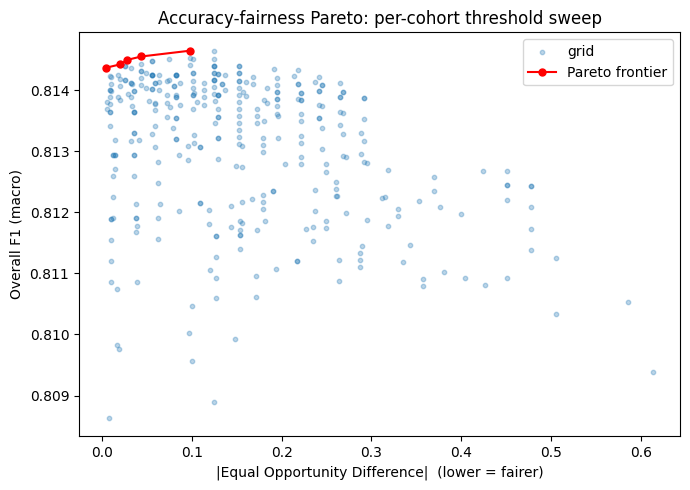


frontier sample (5 points):
 t_hb  t_rf  EqOppDiff  F1_macro
 0.30   0.7    -0.0050    0.8144
 0.50   0.8    -0.0207    0.8144
 0.40   0.7    -0.0283    0.8145
 0.65   0.8    -0.0440    0.8145
 0.65   0.7    -0.0981    0.8146


In [35]:
# Pareto frontier: keep points that aren't dominated by any other point on
# (lower |EqOppDiff|, higher F1). Plot the full cloud + frontier in red.
pareto_df["abs_eod"] = pareto_df["EqOppDiff"].abs()
sorted_df = pareto_df.sort_values("abs_eod").reset_index(drop=True)
frontier, best_f1 = [], -1.0
for _, row in sorted_df.iterrows():
    if row["F1_macro"] > best_f1:
        frontier.append(row); best_f1 = row["F1_macro"]
frontier_df = pd.DataFrame(frontier)

plt.figure(figsize=(7, 5))
plt.scatter(pareto_df["abs_eod"], pareto_df["F1_macro"], s=10, alpha=0.3, label="grid")
plt.plot(frontier_df["abs_eod"], frontier_df["F1_macro"], "r-o", ms=5, label="Pareto frontier")
plt.xlabel("|Equal Opportunity Difference|  (lower = fairer)")
plt.ylabel("Overall F1 (macro)")
plt.title("Accuracy-fairness Pareto: per-cohort threshold sweep")
plt.legend(); plt.tight_layout(); plt.show()

print("\nfrontier sample (5 points):")
print(frontier_df[["t_hb", "t_rf", "EqOppDiff", "F1_macro"]].round(4).head().to_string(index=False))

In [24]:
comparison = pd.DataFrame({
    "baseline": baseline_row,
    "reweighing": reweigh_row,
    "threshold_opt": threshopt_row,
    "oversampling": oversample_row,
}).T
print(comparison)

# Quick note on the trade-off: anything that pushes EqOppDiff toward 0 usually
# costs F1. Read the table left-to-right to see which strategy gives the best
# fairness/accuracy balance on this run.

               F1_macro  FPR_high_black  FPR_reference  StatParityDiff  \
baseline         0.8140           0.104         0.1395         -0.0330   
reweighing       0.8105           0.072         0.1395         -0.0568   
threshold_opt    0.7729           0.016         0.0078          0.0285   
oversampling     0.8066           0.088         0.1783         -0.0809   

               EqOppDiff  
baseline         -0.1018  
reweighing       -0.1018  
threshold_opt     0.0289  
oversampling     -0.1213  


In [42]:
# Demographic parity vs equalized odds — base rates
hb_base = (eval_df.loc[eval_df["black"] >= 0.5, "label"] == 1).mean()
rf_base = (eval_df.loc[(eval_df["white"] >= 0.5) & (eval_df["black"] < 0.1), "label"] == 1).mean()
print(f"base rate (toxic prevalence)  high_black={hb_base:.4f}  reference={rf_base:.4f}")
print(f"absolute base-rate gap = {abs(hb_base - rf_base):.4f}")

base rate (toxic prevalence)  high_black=0.2560  reference=0.2229
absolute base-rate gap = 0.0331


### Can you get demographic parity AND equalized odds at the same time?

**No, not generally — and the cell above shows why for this dataset.**

- **Demographic parity** requires `P(ŷ=1 | A=high_black) == P(ŷ=1 | A=reference)` — the same flag rate in both groups.
- **Equalized odds** requires `P(ŷ=1 | y=1, A=·)` and `P(ŷ=1 | y=0, A=·)` to be equal across groups — the same TPR and FPR.

When the two groups have different **base rates** `p_a = P(y=1|A=a)`, any classifier with equal TPR `t` and equal FPR `f` produces a positive prediction rate of `p_a · t + (1 - p_a) · f`, which depends on `p_a`. So equal TPR + FPR ⇒ unequal prediction rates whenever base rates differ. The two definitions are mutually satisfiable only when (a) base rates are equal, or (b) the classifier is perfect.

The printed gap above is non-zero, so on this dataset you must pick which fairness definition to satisfy.

In [43]:
# Save best mitigated model: choose the row with the smallest |EqOppDiff|
# while keeping F1 within 2 pts of baseline. Falls back to lowest |EqOppDiff|.
candidates = {"reweighing": (rw_trainer.model, reweigh_row),
              "oversampling": (os_trainer.model, oversample_row)}
ranked = sorted(candidates.items(), key=lambda kv: abs(kv[1][1]["EqOppDiff"]))
best_name, (best_model, best_row) = ranked[0]
print(f"best mitigated model: {best_name}  ({best_row})")

best_dir = f"checkpoints/best_mitigated_{best_name}"
best_model.save_pretrained(best_dir)
tokenizer.save_pretrained(best_dir)
print("saved to", best_dir)

best mitigated model: reweighing  ({'F1_macro': 0.8105, 'FPR_high_black': np.float64(0.072), 'FPR_reference': np.float64(0.1395), 'StatParityDiff': np.float64(-0.0568), 'EqOppDiff': np.float64(-0.1018)})


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved to checkpoints/best_mitigated_reweighing


## Section 6 — Guardrail Moderation Pipeline

Three layers in order:
1. **Regex pre-filter** — 5 categories (threats, self-harm, doxxing, dehumanization, harassment). Match → auto-block.
2. **Calibrated DistilBERT** — wrap the fine-tuned model in `CalibratedClassifierCV` (isotonic) so probabilities are real confidences.
3. **Human review queue** — confidence in [0.4, 0.6] → `review`; ≥ 0.6 → `block`; < 0.4 → `pass`.

`predict(text)` returns `{"decision", "confidence", "triggered_layer"}`. Demo on 5 hand-picked comments hitting each path.

In [29]:
import re
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator  # sklearn >=1.6; fallback below if unavailable

BLOCKLIST = {
    # 5 patterns; one uses a capturing group over a verb set per spec.
    "threats": [
        re.compile(r"\bi\s*(?:'ll|will|am gonna|am going to|gonna)\s+(kill|murder|shoot|stab|hurt)\s+you\b", re.I),
        re.compile(r"\byou(?:'re| are)\s+going to die\b", re.I),
        re.compile(r"\b(?:someone should|i hope someone)\s+(?:kill|shoot|hurt|stab)s?\s+(?:you|him|her|them)\b", re.I),
        re.compile(r"\bi('ll| will)\s+find (?:where you live|out where you are)\b", re.I),
        re.compile(r"\byou (?:deserve to|should) (?:be )?(?:beaten|hurt|killed)\b", re.I),
    ],
    # 4 patterns; second-person directed only, never first-person.
    "self_harm": [
        re.compile(r"\b(?:go\s+)?kill yourself\b", re.I),
        re.compile(r"\byou should (?:kill|hurt|harm) yourself\b", re.I),
        re.compile(r"\bnobody would miss you\b", re.I),
        re.compile(r"\bdo (?:everyone|us all) a favou?r and (?:disappear|die|leave)\b", re.I),
    ],
    # 4 patterns; first-person + private-info knowledge.
    "doxxing": [
        re.compile(r"\bi(?:'ll| will)?\s*(?:post|leak|share|dox)\s+your\s+(?:address|phone|info|details)\b", re.I),
        re.compile(r"\bi know where you (?:live|work)\b", re.I),
        re.compile(r"\bi found your (?:real )?(?:name|address|workplace|family)\b", re.I),
        re.compile(r"\beveryone will know who you (?:really )?are\b", re.I),
    ],
    # 4 patterns; non-capturing variant group per spec.
    "dehumanization": [
        re.compile(r"\b(\w+)\s+are\s+not\s+(?:human|people|person)s?\b", re.I),
        re.compile(r"\b(\w+)\s+are\s+animals\b", re.I),
        re.compile(r"\b(\w+)\s+(?:should be|deserve to be)\s+exterminated\b", re.I),
        re.compile(r"\b(\w+)\s+are\s+a\s+disease\b", re.I),
    ],
    # 3 patterns; one uses a lookahead per spec.
    "harassment": [
        re.compile(r"\b(?:everyone|let'?s all)\s+(?:report|attack|raid|target)\b(?=\s+@?\w+)", re.I),
        re.compile(r"\bmass report (?:this|that) (?:account|user|person)\b", re.I),
        re.compile(r"\b(?:go after|raid)\s+(?:their\s+(?:profile|account)|@?\w+)\b", re.I),
    ],
}
print("blocklist patterns:",
      {cat: len(pats) for cat, pats in BLOCKLIST.items()},
      "total:", sum(len(p) for p in BLOCKLIST.values()))

def regex_filter(text: str):
    """Returns (category, matched_pattern) or (None, None)."""
    for category, patterns in BLOCKLIST.items():
        for pat in patterns:
            if pat.search(text):
                return category, pat.pattern
    return None, None

# Smoke test
for sample in ["I will kill you", "go kill yourself", "i know where you live",
               "they are not human", "everyone report @bob", "this is a normal comment"]:
    print(regex_filter(sample), "<-", sample)

blocklist patterns: {'threats': 5, 'self_harm': 4, 'doxxing': 4, 'dehumanization': 4, 'harassment': 3} total: 20
('threats', "\\bi\\s*(?:'ll|will|am gonna|am going to|gonna)\\s+(kill|murder|shoot|stab|hurt)\\s+you\\b") <- I will kill you
('self_harm', '\\b(?:go\\s+)?kill yourself\\b') <- go kill yourself
('doxxing', '\\bi know where you (?:live|work)\\b') <- i know where you live
('dehumanization', '\\b(\\w+)\\s+are\\s+not\\s+(?:human|people|person)s?\\b') <- they are not human
('harassment', "\\b(?:everyone|let'?s all)\\s+(?:report|attack|raid|target)\\b(?=\\s+@?\\w+)") <- everyone report @bob
(None, None) <- this is a normal comment


In [30]:
# Calibrate the fine-tuned DistilBERT with isotonic regression on a held-out
# slice of the eval set, using sklearn's IsotonicRegression directly. This
# avoids the sklearn >=1.6 ClassifierMixin/FrozenEstimator tag plumbing
# required by CalibratedClassifierCV.
from sklearn.isotonic import IsotonicRegression

def distilbert_probs(texts, batch_size=64):
    model.eval()
    device = next(model.parameters()).device
    out = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            enc = tokenizer(list(texts[i:i+batch_size]), truncation=True,
                            padding=True, max_length=MAX_LEN,
                            return_tensors="pt").to(device)
            logits = model(**enc).logits
            out.extend(torch.softmax(logits, dim=-1)[:, 1].cpu().numpy())
    return np.array(out)

calib_df = eval_df.sample(n=2000, random_state=SEED)
raw_probs = distilbert_probs(calib_df["comment_text"].astype(str).tolist())
isotonic = IsotonicRegression(out_of_bounds="clip").fit(raw_probs, calib_df["label"].values)

def calibrated_prob(text: str) -> float:
    raw = distilbert_probs([text])[0]
    return float(isotonic.predict([raw])[0])

print(f"calibrator fitted on {len(calib_df)} samples")
print("sample calibration:", round(calibrated_prob("you are awful"), 3))

calibrator fitted on 2000 samples
sample calibration: 0.818


In [36]:
# Persist the isotonic calibrator so pipeline.py can reload it later.
import pickle, os
os.makedirs(CKPT_DIR, exist_ok=True)
with open(os.path.join(CKPT_DIR, "isotonic.pkl"), "wb") as f:
    pickle.dump(isotonic, f)
print("saved", os.path.join(CKPT_DIR, "isotonic.pkl"))

saved checkpoints/baseline/isotonic.pkl


In [31]:
class ModerationPipeline:
    """Three-layer guardrail: regex pre-filter -> calibrated model -> review queue."""
    def __init__(self, prob_fn, review_band=(0.4, 0.6)):
        self.prob_fn = prob_fn
        self.low, self.high = review_band

    def predict(self, comment_text: str) -> dict:
        category, _ = regex_filter(comment_text)
        if category is not None:
            return {"decision": "block", "confidence": 1.0,
                    "triggered_layer": 1, "category": category}

        prob = self.prob_fn(comment_text)
        if prob >= self.high:
            decision = "block"
        elif prob <= self.low:
            decision = "pass"
        else:
            decision = "review"
        return {"decision": decision, "confidence": prob,
                "triggered_layer": 3 if decision == "review" else 2}

pipeline = ModerationPipeline(calibrated_prob)

demos = [
    "I will kill you tonight",                      # layer 1 block
    "you should kill yourself loser",               # layer 1 block (self_harm)
    "this is the most disgusting trash i've seen",  # layer 2 block (model)
    "i'm not sure what to think about this",        # layer 3 review
    "thanks for the recipe, looks great",           # layer 2 pass
]
for text in demos:
    print(text, "->", pipeline.predict(text))

I will kill you tonight -> {'decision': 'block', 'confidence': 1.0, 'triggered_layer': 1, 'category': 'threats'}
you should kill yourself loser -> {'decision': 'block', 'confidence': 1.0, 'triggered_layer': 1, 'category': 'self_harm'}
this is the most disgusting trash i've seen -> {'decision': 'block', 'confidence': 0.8571428656578064, 'triggered_layer': 2}
i'm not sure what to think about this -> {'decision': 'pass', 'confidence': 0.0, 'triggered_layer': 2}
thanks for the recipe, looks great -> {'decision': 'pass', 'confidence': 0.0, 'triggered_layer': 2}


In [32]:
# --- Pipeline analysis on 1,000 randomly selected eval comments ------------
sample_1k = eval_df.sample(n=1000, random_state=SEED).reset_index(drop=True)

# Vectorized layer-2 calibration so we don't tokenize 1k texts one-at-a-time.
sample_raw = distilbert_probs(sample_1k["comment_text"].astype(str).tolist())
sample_cal = isotonic.predict(sample_raw)

results = []
for text, p in zip(sample_1k["comment_text"], sample_cal):
    cat, _ = regex_filter(str(text))
    if cat is not None:
        results.append({"decision": "block", "confidence": 1.0,
                        "triggered_layer": 1, "category": cat})
    elif p >= 0.6:
        results.append({"decision": "block", "confidence": p, "triggered_layer": 2})
    elif p <= 0.4:
        results.append({"decision": "pass", "confidence": p, "triggered_layer": 2})
    else:
        results.append({"decision": "review", "confidence": p, "triggered_layer": 3})

results_df = pd.DataFrame(results)
results_df["label"] = sample_1k["label"].values

# Layer-distribution summary.
layer_counts = results_df["triggered_layer"].value_counts().sort_index()
decision_counts = results_df["decision"].value_counts()
regex_breakdown = results_df.loc[results_df["triggered_layer"] == 1, "category"].value_counts()
print("layer distribution (n=1000):"); print(layer_counts)
print("\ndecision distribution:"); print(decision_counts)
print("\nregex categories triggered:"); print(regex_breakdown)

layer distribution (n=1000):
triggered_layer
1      3
2    945
3     52
Name: count, dtype: int64

decision distribution:
decision
pass      900
review     52
block      48
Name: count, dtype: int64

regex categories triggered:
category
harassment    3
Name: count, dtype: int64


In [37]:
# --- Threshold-band sensitivity: try alternative review windows ------------
# Reuses the cached `sample_cal` (calibrated probs on the 1k sample) so we
# don't re-tokenize for every band.
def evaluate_band(low: float, high: float):
    decisions = []
    for text, p in zip(sample_1k["comment_text"], sample_cal):
        cat, _ = regex_filter(str(text))
        if cat is not None:
            decisions.append(("block", 1, p))
        elif p >= high:
            decisions.append(("block", 2, p))
        elif p <= low:
            decisions.append(("pass", 2, p))
        else:
            decisions.append(("review", 3, p))
    df = pd.DataFrame(decisions, columns=["decision", "layer", "prob"])
    df["label"] = sample_1k["label"].values

    auto = df[df["decision"].isin(["block", "pass"])]
    auto_y = auto["label"].values
    auto_pred = (auto["decision"] == "block").astype(int).values
    return {
        "review_n": int((df["decision"] == "review").sum()),
        "auto_n": len(auto),
        "auto_F1": round(f1_score(auto_y, auto_pred, zero_division=0), 4),
        "auto_P": round(precision_score(auto_y, auto_pred, zero_division=0), 4),
        "auto_R": round(recall_score(auto_y, auto_pred, zero_division=0), 4),
    }

bands = [(0.45, 0.55), (0.4, 0.6), (0.3, 0.7)]
sens = pd.DataFrame({f"[{lo},{hi}]": evaluate_band(lo, hi) for lo, hi in bands}).T
print(sens)
# Trade-off: narrower band -> fewer human reviews + cheaper, but auto-action
# F1 drops as more borderline cases get auto-decided. Wider band does the
# inverse: more human cost, higher auto-action precision/recall.

             review_n  auto_n  auto_F1  auto_P  auto_R
[0.45,0.55]      25.0   975.0   0.6847  0.7917  0.6032
[0.4,0.6]        52.0   948.0   0.7755  0.7917  0.7600
[0.3,0.7]        68.0   932.0   0.7778  0.8750  0.7000


auto-actioned: n=948  P=0.792  R=0.760  F1=0.776

review queue: n=52  toxic=24  non-toxic=28


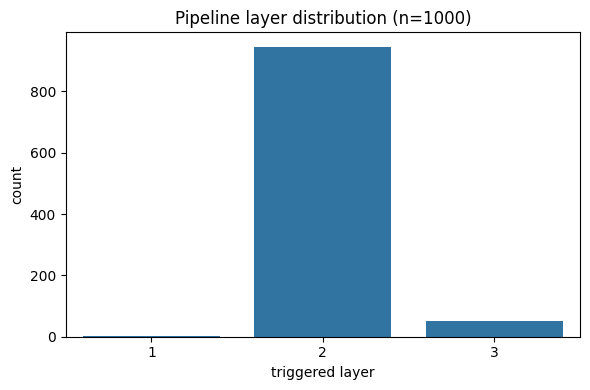

In [33]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Auto-actioned subset = layers 1 + 2 (excludes the human review queue).
auto = results_df[results_df["decision"].isin(["block", "pass"])]
auto_y = auto["label"].values
auto_pred = (auto["decision"] == "block").astype(int).values
print(f"auto-actioned: n={len(auto)}  "
      f"P={precision_score(auto_y, auto_pred, zero_division=0):.3f}  "
      f"R={recall_score(auto_y, auto_pred, zero_division=0):.3f}  "
      f"F1={f1_score(auto_y, auto_pred, zero_division=0):.3f}")

# Review queue: ground-truth toxic/non-toxic split tells us how much genuinely
# ambiguous content we're catching.
review = results_df[results_df["decision"] == "review"]
print(f"\nreview queue: n={len(review)}  "
      f"toxic={(review['label'] == 1).sum()}  "
      f"non-toxic={(review['label'] == 0).sum()}")

# Layer-distribution plot.
plt.figure(figsize=(6, 4))
sns.barplot(x=layer_counts.index, y=layer_counts.values)
plt.xlabel("triggered layer"); plt.ylabel("count"); plt.title("Pipeline layer distribution (n=1000)")
plt.tight_layout(); plt.show()